In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# **Metode Numerik untuk Masalah Nilai Awal (Numerical Methods for Initial Value Problems)**

Metode numerik untuk sistem ODE (Ordinary Differential Equations) yang merupakan *masalah nilai awal* dengan bentuk umum:

$$
\frac{\text{d} \vec{u}}{\text{d}t} = \vec{f}(t, \vec{u}), \quad \vec{u}(0) = \vec{u}_0
$$

Keterangan:
- $\vec{u}(t)$ adalah vektor keadaan (state vector)
- $\vec{f}(t, \vec{u})$ adalah fungsi bernilai vektor yang mengatur pertumbuhan atau perubahan $\vec{u}$ terhadap waktu  
- $\vec{u}(0)$ adalah kondisi awal pada waktu $t = 0$

Bahwa fungsi ruas kanan $\vec{f}$ sebenarnya bisa merupakan hasil dari **diskretisasi ruang suatu PDE**, yaitu berupa sebuah sistem persamaan.

#### **Contoh: Peluruhan Radioaktif Sederhana**
Peluruhan radioaktif sederhana adalah model fisik yang bisa ditulis dan diselesaikan sebagai IVP.

IVP = kerangka matematisnya

Peluruhan radioaktif = contoh kasusnya

$\vec{u} = [c]$

$$
\frac{\text{d} c}{\text{d}t} = -\lambda c \quad c(0) = c_0
$$

yang memiliki solusi dalam bentuk:
$$
c(t) = c_0 e^{-\lambda t}
$$

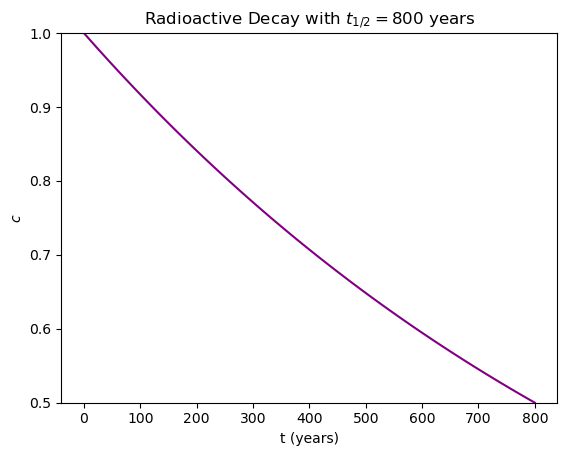

In [14]:
# Membuat array waktu dari 0 sampai 800 tahun (100 titik data)
t = numpy.linspace(0.0, 800.0, 100)

# Nilai awal konsentrasi
c_0 = 1.0

# Waktu paruh (tahun)
t_half = 800.0

# Menghitung konstanta peluruhan (lambda = ln(2)/t_half)
decay_constant = numpy.log(2.0) / t_half

# Membuat figure (area grafik)
fig = plt.figure()

# Membuat satu subplot (1 baris, 1 kolom, posisi ke-1)
axes = fig.add_subplot(1, 1, 1)

# Plot kurva peluruhan eksponensial: c(t) = c0 * exp(-lambda * t)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), color='purple')

# Memberi judul grafik
axes.set_title("Radioactive Decay with $t_{1/2} = 800$ years")

# Label sumbu x (waktu)
axes.set_xlabel('t (years)')

# Label sumbu y (konsentrasi)
axes.set_ylabel('$c$')

# Membatasi tampilan sumbu y (agar fokus di bagian atas)
axes.set_ylim((0.5, 1.0))

# Menampilkan grafik
plt.show()

#### **Contoh: Peluruhan radioaktif kompleks (atau sistem kimia)**
Rantai peluruhan dari satu spesies ke spesies lainnya

$$\begin{aligned}
    \frac{\text{d} c_1}{\text{d}t} &= -\lambda_1 c_1 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_1 c_1 - \lambda_2 c_2 \\
    \frac{\text{d} c_3}{\text{d}t} &= \lambda_2 c_2 - \lambda_3 c_3
\end{aligned}$$

$$\frac{\text{d} \vec{u}}{\text{d}t} = \frac{\text{d}}{\text{d}t}\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix} = 
\begin{bmatrix} 
    -\lambda_1 & 0 & 0 \\
    \lambda_1 & -\lambda_2 & 0 \\
    0 & \lambda_2 & -\lambda_3
\end{bmatrix} \begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}$$

$$\frac{\text{d} \vec{u}}{\text{d}t} = A \vec{u}$$

Untuk sistem persamaan seperti ini, solusi umum dari ODE adalah eksponensial matriks:

$$\vec{u}(t) = e^{A t} \vec{u}_0$$

## **Keberadaan dan Keunikan Solusi**

Salah satu langkah penting sebelum mempelajari metode numerik untuk masalah ODE IVP adalah memahami perilaku solusi, apakah solusi tersebut ada, dan apakah solusi tersebut mungkin unik.

### **Sistem Linear**

Untuk ODE linear, kita memiliki sistem umum:
$$
u'(t) = A(t)\, u + g(t)
$$
di mana $A$ adalah matriks yang bergantung pada waktu dan $g$ adalah sebuah vektor. Perlu dicatat bahwa sistem linear selalu memiliki solusi yang unik. Hal ini karena bentuknya linear, sehingga tidak terjadi “percabangan solusi” seperti pada beberapa sistem non-linear.

Jika $g(t) = 0$ untuk semua $t$, maka ODE disebut *homogen*. Jika matriks $A$ tidak bergantung pada waktu (konstan), maka sistem tersebut juga disebut *otonom*. Solusi dari ODE ini adalah:
$$
u(t) = u(t_0)\, e^{A(t - t_0)}.
$$
Penjelasannya: eksponensial matriks $e^{A(t - t_0)}$ berperan sebagai “penggerak” solusi dari kondisi awal $u(t_0)$ ke waktu $t$. Ini mirip dengan solusi skalar $e^{kt}$ pada persamaan diferensial biasa, tetapi diperluas ke bentuk matriks.

Dalam kasus di mana $g(t) \neq 0$ untuk semua $t$, ODE disebut *tak homogen*. Kita dapat menggunakan prinsip Duhamel, yang menyatakan bahwa:
$$
u(t) = u(t_0)\, e^{A(t - t_0)} + \int_{t_0}^{t} e^{A(t - \tau)} g(\tau)\, d\tau.
$$

Penjelasannya:
- Suku pertama $u(t_0)e^{A(t-t_0)}$ adalah solusi dari bagian homogen (tanpa gaya luar).
- Suku integral menggambarkan pengaruh “gaya luar” $g(t)$ terhadap sistem sepanjang waktu dari $t_0$ hingga $t$.
- Setiap kontribusi $g(\tau)$ pada waktu $\tau$ “dipropagasikan” ke waktu $t$ بواسطة operator $e^{A(t-\tau)}$.

Operator $e^{A(t-\tau)}$ dapat dipandang sebagai operator solusi untuk ODE homogen, yang memetakan solusi dari waktu $\tau$ ke waktu $t$. Karena itu, bentuk solusi ini memiliki sifat seperti fungsi Green, yaitu mengakumulasi efek dari sumber $g(t)$ sepanjang waktu untuk membentuk solusi total.

### **Eksistensi dan Keunikan Non-linier**

#### **Kontinuitas Lipschitz**

Untuk menggeneralisasi keunikan solusi pada ODE non-linear, diperlukan jenis kekontinuan khusus yang disebut *kontinuitas Lipschitz*. Perhatikan ODE berikut:
$$
u'(t) = f(u,t), \quad \quad \quad u(t_0) = u_0,
$$
kita memerlukan tingkat kehalusan (smoothness) tertentu pada fungsi ruas kanan $f(u,t)$ agar solusi tidak “menyimpang” atau menjadi tidak tunggal.

Kita mengatakan bahwa $f$ bersifat *Lipschitz kontinu* terhadap $u$ pada suatu domain
$$
\Omega = \{(u,t) : |u - u_0| \leq a,\; t_0 \leq t \leq t_1 \}
$$
jika terdapat suatu konstanta $L > 0$ sehingga
$$
|f(u,t) - f(u^\ast, t)| \leq L |u - u^\ast| \quad \quad \forall (u,t), (u^\ast,t) \in \Omega.
$$

Penjelasan:
- Kondisi ini membatasi seberapa cepat $f$ berubah terhadap $u$.
- Secara intuitif, fungsi tidak boleh “terlalu curam” atau berubah drastis dalam jarak kecil.
- Konstanta $L$ disebut *konstanta Lipschitz* dan mengontrol tingkat perubahan tersebut.

Jika $f(u,t)$ terdiferensialkan terhadap $u$ di $\Omega$, yaitu turunan Jacobian $f_u = \partial f / \partial u$ ada dan terbatas, maka kita dapat menuliskan
$$
L = \max_{(u,t) \in \Omega} |f_u(u,t)|.
$$

Batas ini dapat digunakan karena
$$
f(u,t) = f(u^\ast, t) + f_u(v,t)(u-u^\ast)
$$
untuk suatu $v$ yang berada di antara $u$ dan $u^\ast$. Ini merupakan bentuk pendekatan deret Taylor orde pertama, yang menunjukkan bahwa perubahan fungsi dapat diperkirakan secara linear di sekitar titik tertentu.

Dengan adanya sifat Lipschitz pada $f$, kita dapat menjamin bahwa solusi IVP (Initial Value Problem) adalah unik, setidaknya hingga waktu
$$
T = \min(t_1, t_0 + a/S)
$$
dengan
$$
S = \max_{(u,t)\in\Omega} |f(u,t)|.
$$

- Nilai $S$ merupakan batas maksimum laju perubahan solusi $u(t)$.
- Batas waktu $T$ memastikan bahwa solusi tidak keluar dari domain $\Omega$.
- Intinya, kondisi Lipschitz menjamin dua hal penting: eksistensi dan keunikan solusi, setidaknya dalam selang waktu tertentu.

#### **Contoh: Kegagalan Lipschitz (Solusi Tidak Unik)**

Pertimbangkan persamaan diferensial:
$$
u'(t) = u^{1/3}, \quad u(0) = 0
$$

Misalkan:
$$
f(u) = u^{1/3}
$$

Turunan terhadap $u$:
$$
f_u = \frac{1}{3} u^{-2/3}
$$

Perhatikan:
- Saat $u \to 0$, maka $f_u \to \infty$
- Jadi fungsi tidak Lipschitz di sekitar $u = 0$

##### Solusi trivial
$$
u(t) = 0
$$

Solusi $u(t) = 0$ disebut sebagai solusi trivial karena merupakan solusi paling sederhana dari persamaan diferensial yang diberikan. Jika kita substitusikan ke dalam persamaan
$$
u'(t) = u^{1/3},
$$
diperoleh bahwa turunan dari $u(t) = 0$ adalah
$$
u'(t) = 0,
$$
sedangkan ruas kanan menjadi
$$
0^{1/3} = 0.
$$

Maka, kedua ruas persamaan sama, sehingga persamaan diferensial terpenuhi. Selain itu, solusi ini juga memenuhi kondisi awal
$$
u(0) = 0,
$$

##### Solusi non-trivial
Pisahkan variabel:
$$
\frac{du}{u^{1/3}} = dt
$$

Integrasi:
$$
u^{2/3} = \frac{2}{3} t + C
$$

Gunakan kondisi awal:
$$
u(0) = 0 \Rightarrow C = 0
$$

Sehingga:
$$
u(t) = \left(\frac{2}{3} t\right)^{3/2}
$$

Didapat dua solusi:
$$
u(t) = 0
\quad \text{dan} \quad
u(t) = \left(\frac{2}{3} t\right)^{3/2}
$$

##### Solusi Lebih Umum

Untuk sembarang $t_0 \ge 0$:
$$
u(t) =
\begin{cases}
0, & t \leq t_0 \\
\left(\frac{2}{3}(t - t_0)\right)^{3/2}, & t > t_0
\end{cases}
$$

#### **Sistem Persamaan**


Konsep yang serupa untuk kekontinuan Lipschitz juga berlaku pada sistem persamaan dengan menggunakan suatu norma tertentu $||\cdot||$. Dikatakan bahwa $f$ bersifat Lipschitz jika terdapat konstanta $L$ sehingga:
$$
||f(u,t) - f(u^\ast,t)|| \leq L \, ||u - u^\ast||
$$
untuk semua $(u,t)$ dan $(u^\ast,t)$ dalam domain
$$
\Omega = \{(u,t) : ||u-u_0|| \leq a,\; t_0 \leq t \leq t_1 \}.
$$

Artinya, jarak antara nilai fungsi $f$ untuk dua titik tidak boleh melebihi konstanta $L$ dikali jarak antara kedua titik tersebut dalam norma yang digunakan.

Pada sistem persamaan, variabel $u$ umumnya berbentuk vektor, sehingga diperlukan norma untuk mengukur besar atau jarak antar vektor. Norma ini bisa berupa norma Euclidean, norma maksimum, atau norma lainnya, tergantung konteks yang digunakan. Syarat Lipschitz dalam bentuk ini memastikan bahwa perubahan kecil pada vektor input $u$ hanya menghasilkan perubahan yang terbatas pada output $f(u,t)$. Dengan kata lain, fungsi tidak berubah secara drastis atau tidak stabil. Hal ini sangat penting dalam analisis sistem ODE karena menjamin bahwa solusi yang diperoleh tidak hanya ada, tetapi juga unik dan stabil terhadap perubahan kondisi awal. Selain itu, meskipun Lipschitz didefinisikan terhadap suatu norma tertentu, dalam ruang berdimensi hingga semua norma bersifat ekuivalen, sehingga jika suatu fungsi Lipschitz dalam satu norma, maka sifat kekontinuannya tetap berlaku dalam norma lainnya.


### **Skema Langkah Dasar (Basic Stepping Schemes)**

Melihat kembali pembahasan kita tentang diferensiasi numerik, kita dapat mendekati turunan menggunakan beda hingga:
$$
\frac{u(t + \Delta t) - u(t)}{\Delta t} = f(t, u)
$$
Namun, kita masih perlu menentukan bagaimana mengevaluasi suku $f(t, u)$ tersebut.

Mari kita lihat dari sudut pandang integrasi (kuadratur), dengan mengintegralkan kedua ruas:

$$\begin{aligned}
\int^{t + \Delta t}_t \frac{\text{d} u}{\text{d}\tilde{t}} d\tilde{t} &= \int^{t + \Delta t}_t f(t, u) d\tilde{t} \\ ~ \\
u(t + \Delta t) - u(t) &= \Delta t ~f(t, u(t)) \\ ~ \\
\frac{u(t + \Delta t) - u(t)}{\Delta t} &= f(t, u(t))
\end{aligned}$$

di mana pada ruas kanan kita menggunakan aturan kuadratur sisi kiri (*left-sided quadrature rule*), yaitu mengambil nilai fungsi di titik awal interval.

Untuk menyederhanakan notasi, kita definisikan:
$$
t_0 = 0 \quad \quad t_1 = t_0 + \Delta t \quad \quad t_n = t_{n-1} + \Delta t = n \Delta t + t_0
$$

$$
U^0 = u(t_0) \quad \quad U^1 = u(t_1) \quad \quad U^n = u(t_n)
$$

Sehingga skema dapat dituliskan sebagai:
$$
\frac{U^{n+1} - U^n}{\Delta t} = f(t_n, U^n)
$$
atau:
$$
U^{n+1} = U^n + \Delta t \, f(t_n, U^n)
$$

Metode ini dikenal sebagai *metode Euler maju* (*forward Euler method*). Pada dasarnya kita mendekati turunan dengan nilai fungsi pada titik waktu $t_n$.